# Import

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import random

notebook_path = os.getcwd()
parent_path = os.path.abspath(os.path.join(notebook_path, '..'))

if parent_path not in sys.path:
    sys.path.append(parent_path)

from market_data import KalshiAnalyzer, KalshiClient, KalshiFeatureEngineer, KalshiResearch

# Test

In [2]:
rspl = KalshiResearch()

series_data = rspl.fetch_series()
series_tickers = list(series_data.ticker.unique())
# series_tickers = random.sample(series_tickers, len(series_tickers)//10)

In [3]:
markets_data = rspl.fetch_markets_from_series(series_tickers)

Extracting Markets: 100%|██████████| 8656/8656 [1:31:12<00:00,  1.58it/s]  


In [4]:
markets_data.to_parquet("market_data.parquet")

In [ ]:
tickers = list(markets_data.ticker.unique())
# tickers = random.sample(tickers, len(tickers)//2)

all_data = rspl.fetch_data(tickers)

Fetching:   1%|          | 174/27569 [00:50<5:08:10,  1.48it/s]

Fetching:  62%|██████▏   | 17216/27569 [2:23:28<2:30:18,  1.15it/s] 

In [ ]:
all_data.to_parquet("all_data.parquet")

In [ ]:
def my_custom_features(df):
    processed_df = pd.DataFrame()
    processed_df['volatility_id'] = (df['high'] - df['low']) / df['open'].replace(0,np.nan)
    shifted_close = df.groupby(level=1)['close'].shift(1)
    processed_df['return'] = (df['close'] / shifted_close.replace(0,np.nan)) - 1    
    processed_df['price_loc'] = (df['close'] - df['low']) / (df['high'] - df['low'] + 1e-9)
    processed_df['body_ratio'] = np.abs(df['close'] - df['open']) / (df['high'] - df['low'] + 1e-9)
    processed_df['dollar_volume'] = df['volume'] * df['mean_dollars']
    processed_df['mean_dev'] = (df['close_dollars'] - df['mean_dollars']) / df['mean_dollars'].replace(0,np.nan)
    return processed_df

X, y = rspl.prepare_ml_ready(my_custom_features)

Executing custom feature engineering...


In [ ]:
import lightgbm as lgbm

model = lgbm.LGBMRegressor(n_estimators=100, learning_rate=0.05, verbosity=-1)
bt = rspl.run_backtest(model)

Backtesting: 100%|██████████| 989/989 [00:24<00:00, 39.81it/s]


In [ ]:
bt[0].to_parquet("pnl_results_bt.parquet")
bt[1].to_parquet("metrics_bt.parquet")

In [ ]:
raw_pnl_mat = bt[0].reset_index().pivot(index = "ts", columns = "ticker", values = "raw_pnl").sum(1)
norm_pnl_mat = bt[0].reset_index().pivot(index = "ts", columns = "ticker", values = "norm_pnl").sum(1)

np.float64(2.7225179844820806)

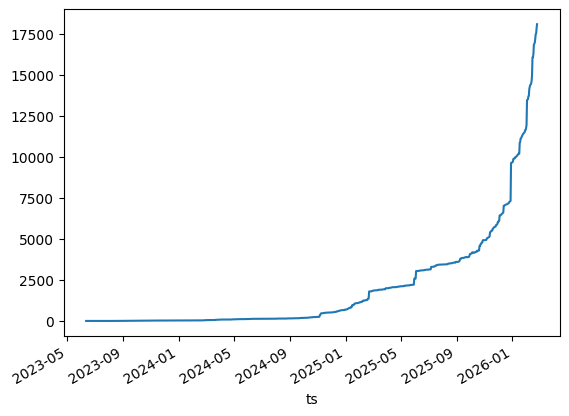

In [ ]:
raw_pnl_mat.cumsum().plot()
16*raw_pnl_mat.mean()/raw_pnl_mat.std()

(np.float64(4.118280755622281), np.float64(6840.7903110720645))

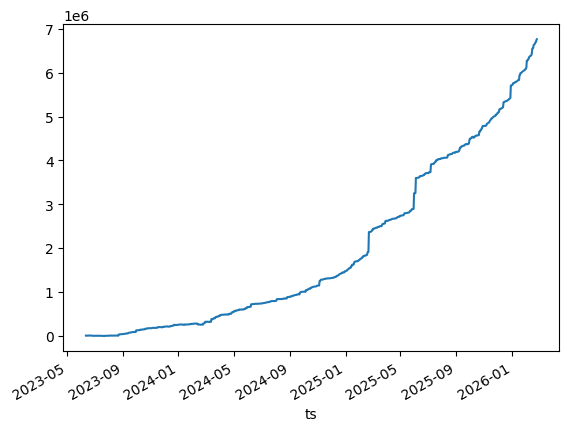

In [ ]:
VaR = 1e4
(VaR*norm_pnl_mat).cumsum().plot()
16*norm_pnl_mat.mean()/norm_pnl_mat.std(), norm_pnl_mat.mean()*1e4 